# HHT-CFI NBA Trajectory: Load, Evaluate, Experiment

Load the trained checkpoint, compute ADE/FDE/MSE metrics, visualize predictions, and optionally experiment with retraining.

## Setup: Imports, paths, device

In [16]:
%load_ext autoreload
%autoreload 2

import sys
import os
import json
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import display, HTML

import lightning as L

# Paths
_ROOT = Path('/home/kolhe/network_ml_project')
_SRC  = _ROOT / 'src'

sys.path.insert(0, str(_SRC))

from hht_cfi.hht_cfi_nba import (
    NBADataModule, NBAHHTCFIModel, NBAHHTCFILightningModel,
    _to_hht_inputs
)
from utils.metrics import compute_ade, compute_fde, compute_mse, compute_min_ade, compute_min_fde, compute_min_mse

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
L.seed_everything(0)

[rank: 0] Seed set to 0


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda


0

## Data: Load datamodule and verify data exists

In [9]:
# Build datamodule
dm = NBADataModule(
    split_path=str(_ROOT / 'splits' / 'fold0.json'),
    batch_size=16,
    context_size=8,
    horizon_size=12,
    seed=0
)

# Check that data dir exists
manifest = json.loads(Path(dm.split_path).read_text())
data_dir = _ROOT / manifest['data_dir']
print(f"Data dir: {data_dir}")
print(f"Data dir exists: {data_dir.exists()}")

if not data_dir.exists():
    print("\n⚠️  WARNING: Data directory does not exist on this machine!")
    print(f"   Expected: {data_dir}")
    print("\n   To fix, copy from Windows machine or re-download from Kaggle:")
    print("   1. Download nml-2026 competition data from kaggle.com/competitions/nml-2026/data")
    print(f"   2. Extract to: {data_dir}")
    print("\n   Then re-run this cell.")
else:
    print(f"✓ Found {len(list(data_dir.glob('*.pt')))} .pt files")
    dm.setup()
    print(f"✓ DataModule ready: {len(dm.train_ds)} train, {len(dm.val_ds)} val sequences")
    print(f"✓ Global normalization: mu={dm.mu}, sigma={dm.sigma}")

Data dir: /home/kolhe/network_ml_project/data/train/train
Data dir exists: True
✓ Found 4968 .pt files
✓ DataModule ready: 4471 train, 497 val sequences
✓ Global normalization: mu=tensor([0.4308, 0.0420]), sigma=tensor([29.6707, 11.5475])


## Load checkpoint

In [17]:
ckpt_dir   = _ROOT / 'logs' / 'hht_cfi' / 'version_0' / 'checkpoints'
ckpt_files = sorted(ckpt_dir.glob('*.ckpt'))

if not ckpt_files:
    print(f"No checkpoints found in {ckpt_dir}")
else:
    ckpt_path = ckpt_files[-1]
    print(f"Loading: {ckpt_path.name}")

    # strict=False: the original checkpoint stored mu/sigma as buffers (via
    # register_buffer in on_fit_start); the updated model no longer does this,
    # so we skip those keys and reattach from the datamodule below.
    model = NBAHHTCFILightningModel.load_from_checkpoint(
        str(ckpt_path), map_location=device, strict=False
    )
    model = model.to(device)
    model.eval()

    # Attach normalization stats from the datamodule (identical to training)
    model.mu    = dm.mu.to(device)
    model.sigma = dm.sigma.to(device)

    print(f"✓ Loaded.  mu={model.mu}  sigma={model.sigma}")
    print(f"Hyperparameters: {dict(model.hparams)}")

Loading: epoch=57-step=16240.ckpt
✓ Loaded.  mu=tensor([0.4308, 0.0420], device='cuda:0')  sigma=tensor([29.6707, 11.5475], device='cuda:0')
Hyperparameters: {'hidden_size': 64, 'x_encoder_layers': 3, 'x_encoder_head': 8, 'lr': 0.001}


## Sanity check: forward on one batch

In [15]:
# Get one val batch
val_loader = dm.val_dataloader()
X_batch, y_batch = next(iter(val_loader))
X_batch, y_batch = X_batch.to(device), y_batch.to(device)

print(f"Input (X) shape: {X_batch.shape}  — [batch={X_batch.shape[0]}, time={X_batch.shape[1]}, agents={X_batch.shape[2]}, features={X_batch.shape[3]}]")
print(f"Target (y) shape: {y_batch.shape}")

B, T_pred, N, _ = y_batch.shape

with torch.no_grad():
    pred_abs = model.predict_batch(X_batch)          # [T_pred, B*N, 2]

tgt_abs = (y_batch[:, :, :, :2] * model.sigma + model.mu).permute(1, 0, 2, 3).reshape(T_pred, B * N, 2)

ade = compute_ade(pred_abs, tgt_abs)
fde = compute_fde(pred_abs, tgt_abs)
mse = compute_mse(pred_abs, tgt_abs)

print(f"\nMetrics on this batch:")
print(f"  ADE (ft):  {ade.item():.3f}")
print(f"  FDE (ft):  {fde.item():.3f}")
print(f"  MSE (ft²): {mse.item():.3f}")
print(f"  RMSE (ft): {mse.sqrt().item():.3f}")
print(f"\n✓ Forward pass successful.")

Input (X) shape: torch.Size([16, 8, 11, 6])  — [batch=16, time=8, agents=11, features=6]
Target (y) shape: torch.Size([16, 12, 11, 6])

Metrics on this batch:
  ADE (ft):  2.120
  FDE (ft):  4.742
  MSE (ft²): 6.352
  RMSE (ft): 2.520

✓ Forward pass successful.


## Comprehensive evaluation over full validation set

In [43]:
def evaluate_model(model, dm, device):
    """
    Evaluate over full val set using the exact same code path as get_kaggle_submission:
    model.get_trajectory() is called per sample, one sequence at a time.
    """
    model.eval()
    val_loader = dm.val_dataloader()

    T_obs = dm.context_size   # 8
    T_pred = dm.horizon_size  # 12

    all_pred_abs  = []
    all_tgt_abs   = []
    all_obs_abs   = []
    all_is_player = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            B, _, N, _ = X_batch.shape

            for b in range(B):
                traj = model.get_trajectory(X_batch[b], model.mu, model.sigma)  # [T_obs+T_pred, N, 4]
                pred_abs_b = traj[T_obs:, :, :2]                                # [T_pred, N, 2] absolute feet
                obs_abs_b  = traj[:T_obs, :, :2]                                # [T_obs, N, 2]

                tgt_abs_b  = (y_batch[b, :, :, :2] * model.sigma + model.mu).cpu()  # [T_pred, N, 2]
                is_player_b = X_batch[b, 0, :, 4].cpu()                              # [N]

                all_pred_abs.append(pred_abs_b.unsqueeze(1))   # [T_pred, 1, N, 2] → will cat on dim=1 after reshape
                all_tgt_abs.append(tgt_abs_b.unsqueeze(1))
                all_obs_abs.append(obs_abs_b.unsqueeze(1))
                all_is_player.append(is_player_b)

    # Stack: [T_pred, total_samples, N, 2] → reshape to [T_pred, total_samples*N, 2]
    total = len(all_pred_abs)
    pred_all = torch.cat(all_pred_abs, dim=1).reshape(T_pred, total * N, 2)   # [T_pred, total*N, 2]
    tgt_all  = torch.cat(all_tgt_abs,  dim=1).reshape(T_pred, total * N, 2)
    obs_all  = torch.cat(all_obs_abs,  dim=1).reshape(T_obs,  total * N, 2)
    is_player_all = torch.stack(all_is_player).reshape(-1)                     # [total*N]

    player_mask = is_player_all.bool()
    ball_mask   = ~player_mask

    def _metrics(pred, tgt, mask=None):
        p = pred[:, mask] if mask is not None else pred
        t = tgt[:, mask]  if mask is not None else tgt
        if p.shape[1] == 0:
            return dict(ade=float('nan'), fde=float('nan'), mse=float('nan'), rmse=float('nan'))
        return dict(
            ade  = compute_ade(p, t).item(),
            fde  = compute_fde(p, t).item(),
            mse  = compute_mse(p, t).item(),
            rmse = compute_mse(p, t).sqrt().item(),
        )

    per_t_l2  = torch.norm(pred_all - tgt_all, dim=-1).mean(dim=-1)
    per_t_mse = ((pred_all - tgt_all) ** 2).sum(dim=-1).mean(dim=-1)

    return {
        'all':       _metrics(pred_all, tgt_all),
        'players':   _metrics(pred_all, tgt_all, player_mask),
        'ball':      _metrics(pred_all, tgt_all, ball_mask),
        'per_t_l2':  per_t_l2,
        'per_t_mse': per_t_mse,
        'pred_all':  pred_all,
        'tgt_all':   tgt_all,
        'obs_all':   obs_all,
        'is_player': is_player_all,
    }


print("Evaluating over full validation set...")
metrics = evaluate_model(model, dm, device)

def _fmt(m):
    return f"ADE={m['ade']:.4f} ft  FDE={m['fde']:.4f} ft  MSE={m['mse']:.4f} ft²  RMSE={m['rmse']:.4f} ft"

print(f"\n{'='*60}")
print(f"VALIDATION METRICS")
print(f"{'='*60}")
print(f"All agents : {_fmt(metrics['all'])}")
print(f"Players    : {_fmt(metrics['players'])}")
print(f"Ball       : {_fmt(metrics['ball'])}")
print(f"{'='*60}")
print(f"\n→ Kaggle metric (MSE all agents): {metrics['all']['mse']:.4f} ft²")

Evaluating over full validation set...

VALIDATION METRICS
All agents : ADE=2.7112 ft  FDE=6.2371 ft  MSE=10.3702 ft²  RMSE=3.2203 ft
Players    : ADE=2.2094 ft  FDE=5.2652 ft  MSE=5.4433 ft²  RMSE=2.3331 ft
Ball       : ADE=7.7294 ft  FDE=15.9562 ft  MSE=59.6392 ft²  RMSE=7.7226 ft

→ Kaggle metric (MSE all agents): 10.3702 ft²


In [7]:
# ── Full validation evaluation ────────────────────────────────────────────────
from tqdm.auto import tqdm

@torch.no_grad()
def evaluate_model(model, dataloader, device):
    model.eval()

    ade_list     = []
    fde_list     = []
    mse_list     = []
    rmse_list    = []
    min_mse_list = []

    for batch in tqdm(dataloader, desc="Evaluating"):
        X, y = batch
        X = X.to(device)
        y = y.to(device)

        B, T_pred, N = y.shape[0], y.shape[1], y.shape[2]

        # Ground truth in absolute feet
        tgt_abs = (
            y[:, :, :, :2] * model.sigma + model.mu
        ).permute(1, 0, 2, 3).reshape(T_pred, B * N, 2)

        # Single-mode prediction
        pred_abs = model.predict_batch(X)   # [T_pred, B*N, 2]

        # All-modes prediction for minMSE (oracle best-mode)
        all_modes = model.predict_batch_all_modes(X)  # [K=20, T_pred, B*N, 2]

        # Metrics
        ade     = compute_ade(pred_abs, tgt_abs).item()
        fde     = compute_fde(pred_abs, tgt_abs).item()
        mse     = compute_mse(pred_abs, tgt_abs).item()
        rmse    = np.sqrt(mse)
        min_mse = compute_min_mse(all_modes, tgt_abs).item()

        ade_list.append(ade)
        fde_list.append(fde)
        mse_list.append(mse)
        rmse_list.append(rmse)
        min_mse_list.append(min_mse)

    results = {
        "ADE (ft)"     : np.mean(ade_list),
        "FDE (ft)"     : np.mean(fde_list),
        "MSE (ft²)"    : np.mean(mse_list),
        "RMSE (ft)"    : np.mean(rmse_list),
        "minMSE (ft²)" : np.mean(min_mse_list),
    }

    return results


# Run evaluation
val_loader = dm.val_dataloader()

results = evaluate_model(model, val_loader, device)

# Pretty print
results_df = pd.DataFrame([results])

display(results_df.style.format({
    "ADE (ft)"     : "{:.4f}",
    "FDE (ft)"     : "{:.4f}",
    "MSE (ft²)"    : "{:.4f}",
    "RMSE (ft)"    : "{:.4f}",
    "minMSE (ft²)" : "{:.4f}",
}))

print("\nValidation Performance:")
for k, v in results.items():
    print(f"{k:<15}: {v:.4f}")

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

,ADE (ft),FDE (ft),MSE (ft²),RMSE (ft)
0,2.5983,5.9205,19.8269,4.4237



Validation Performance:
ADE (ft)    : 2.5983
FDE (ft)    : 5.9205
MSE (ft²)   : 19.8269
RMSE (ft)   : 4.4237


## Per-timestep error analysis

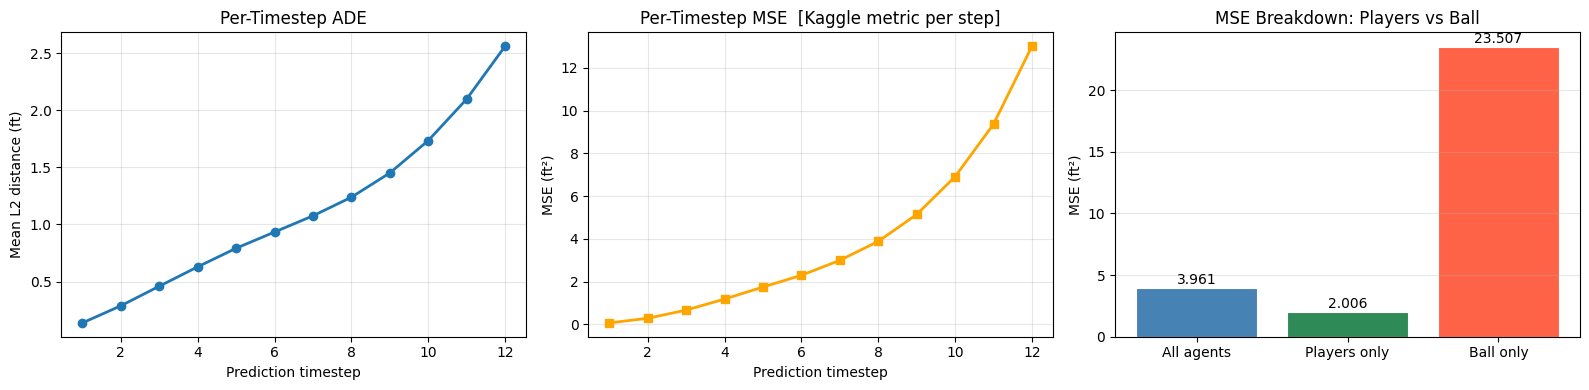


Per-timestep L2 errors (ft):
  t= 1:  L2=0.1390 ft   MSE=0.0656 ft²
  t= 2:  L2=0.2887 ft   MSE=0.2796 ft²
  t= 3:  L2=0.4599 ft   MSE=0.6648 ft²
  t= 4:  L2=0.6294 ft   MSE=1.1801 ft²
  t= 5:  L2=0.7921 ft   MSE=1.7433 ft²
  t= 6:  L2=0.9339 ft   MSE=2.2929 ft²
  t= 7:  L2=1.0758 ft   MSE=2.9930 ft²
  t= 8:  L2=1.2384 ft   MSE=3.8799 ft²
  t= 9:  L2=1.4509 ft   MSE=5.1382 ft²
  t=10:  L2=1.7341 ft   MSE=6.9104 ft²
  t=11:  L2=2.0972 ft   MSE=9.3669 ft²
  t=12:  L2=2.5598 ft   MSE=13.0113 ft²


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
t_steps = np.arange(1, len(metrics['per_t_l2']) + 1)

# Per-timestep L2
axes[0].plot(t_steps, metrics['per_t_l2'].numpy(), 'o-', lw=2, ms=6)
axes[0].set_xlabel('Prediction timestep')
axes[0].set_ylabel('Mean L2 distance (ft)')
axes[0].set_title('Per-Timestep ADE')
axes[0].grid(True, alpha=0.3)

# Per-timestep MSE
axes[1].plot(t_steps, metrics['per_t_mse'].numpy(), 's-', lw=2, ms=6, color='orange')
axes[1].set_xlabel('Prediction timestep')
axes[1].set_ylabel('MSE (ft²)')
axes[1].set_title('Per-Timestep MSE  [Kaggle metric per step]')
axes[1].grid(True, alpha=0.3)

# Player vs ball MSE bar comparison
categories = ['All agents', 'Players only', 'Ball only']
mse_vals   = [metrics['all']['mse'], metrics['players']['mse'], metrics['ball']['mse']]
colors     = ['steelblue', 'seagreen', 'tomato']
bars = axes[2].bar(categories, mse_vals, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, mse_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[2].set_ylabel('MSE (ft²)')
axes[2].set_title('MSE Breakdown: Players vs Ball')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(_ROOT / 'per_timestep_error.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-timestep L2 errors (ft):")
for t, (l2, mse_t) in enumerate(zip(metrics['per_t_l2'].numpy(), metrics['per_t_mse'].numpy()), start=1):
    print(f"  t={t:2d}:  L2={l2:.4f} ft   MSE={mse_t:.4f} ft²")

## Visualize sample predictions

In [ ]:
def draw_court(ax):
    """Draw a simplified NBA half-court outline."""
    from matplotlib.patches import Arc, Circle, Rectangle
    ax.add_patch(Rectangle((-47.5, -25), 95, 50, fill=False, edgecolor='#cccccc', lw=1))
    ax.plot([0, 0], [-25, 25], '--', color='#dddddd', lw=0.8)
    ax.add_patch(Circle((0, 0), 6, fill=False, edgecolor='#dddddd', lw=0.8))
    ax.set_xlim(-52, 52)
    ax.set_ylim(-28, 28)
    ax.set_aspect('equal')


def plot_scene(obs_all, pred_all, tgt_all, is_player, scene_agents, title=""):
    """
    Plot a full scene: 11 agents, observed 8 frames + predicted/target 12 frames.
    scene_agents: list of global indices in obs_all/pred_all for the 11 agents.
    """
    TEAM_COLORS = {1: '#3b82f6', 2: '#ef4444'}
    BALL_COLOR  = '#f59e0b'

    fig, ax = plt.subplots(figsize=(12, 7))
    draw_court(ax)

    for global_i in scene_agents:
        ip      = is_player[global_i].item()
        obs_xy  = obs_all[:, global_i, :].numpy()
        pred_xy = pred_all[:, global_i, :].numpy()
        tgt_xy  = tgt_all[:, global_i, :].numpy()

        if ip:
            team = 1 if obs_xy[-1, 0] < 0 else 2
            col  = TEAM_COLORS[team]
            marker_obs = 'o'
        else:
            col  = BALL_COLOR
            marker_obs = '*'

        ax.plot(obs_xy[:, 0], obs_xy[:, 1],  '-',  color=col, alpha=0.5, lw=1.5)
        ax.plot(obs_xy[-1, 0], obs_xy[-1, 1], marker_obs, color=col, ms=9, zorder=5)
        ax.plot(tgt_xy[:, 0],  tgt_xy[:, 1],  '--', color=col, alpha=0.6, lw=1.5)
        ax.plot(pred_xy[:, 0], pred_xy[:, 1], '-',  color=col, alpha=0.9, lw=1.5)
        ax.plot(pred_xy[-1, 0], pred_xy[-1, 1], '^', color=col, ms=7, zorder=5)

    patches = [
        mpatches.Patch(color='#3b82f6', label='Team A'),
        mpatches.Patch(color='#ef4444', label='Team B'),
        mpatches.Patch(color=BALL_COLOR, label='Ball'),
        plt.Line2D([0], [0], color='grey', ls='-',  lw=1.5, label='Observed (solid)'),
        plt.Line2D([0], [0], color='grey', ls='--', lw=1.5, label='GT future (dashed)'),
        plt.Line2D([0], [0], color='grey', ls='-',  lw=2,   label='Predicted (bright)'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=8, ncol=2)
    ax.set_xlabel('X (ft)')
    ax.set_ylabel('Y (ft)')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    return fig


# ── Grab one val batch and visualize ─────────────────────────────────────────
val_loader = dm.val_dataloader()
X_ex, y_ex = next(iter(val_loader))
X_ex, y_ex = X_ex.to(device), y_ex.to(device)

B_ex, T_pred_ex, N_ex, _ = y_ex.shape

with torch.no_grad():
    pred_abs_ex = model.predict_batch(X_ex).cpu()    # [T_pred, B*N, 2]

tgt_abs_ex   = (y_ex[:, :, :, :2] * model.sigma + model.mu).permute(1, 0, 2, 3).reshape(T_pred_ex, B_ex * N_ex, 2).cpu()
obs_abs_ex   = (X_ex[:, :, :, :2] * model.sigma + model.mu).permute(1, 0, 2, 3).reshape(-1, B_ex * N_ex, 2).cpu()
is_player_ex = X_ex[:, 0, :, 4].reshape(B_ex * N_ex).cpu()

scene_mse_ex = ((pred_abs_ex - tgt_abs_ex) ** 2).sum(-1).mean(0).reshape(B_ex, N_ex).mean(-1)

for scene_idx in range(min(3, B_ex)):
    agents  = list(range(scene_idx * N_ex, (scene_idx + 1) * N_ex))
    mse_val = scene_mse_ex[scene_idx].item()
    fig = plot_scene(obs_abs_ex, pred_abs_ex, tgt_abs_ex, is_player_ex, agents,
                     title=f"Scene {scene_idx} — MSE={mse_val:.3f} ft²")
    plt.savefig(_ROOT / f'scene_{scene_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Training Experiment with WandB

Edit the `HPARAMS` dict below, then run the cell to launch a new training run.  
Training curves will appear live in your WandB project **NML_base**.  
Set `RESUME_CKPT` to a checkpoint path to continue from a previous run.

In [ ]:
import wandb
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger

# ── Hyperparameters ───────────────────────────────────────────────────────────
HPARAMS = dict(
    hidden_size      = 64,
    x_encoder_layers = 3,
    x_encoder_head   = 8,
    lr               = 1e-4,
)
BATCH_SIZE  = 16
MAX_EPOCHS  = 200
PATIENCE    = 25     # early stopping patience on val/mse_ft
GRAD_CLIP   = 1.0
RUN_NAME    = "hht_cfi_run_hetero"   # ← change this for each new experiment

# Set to a .ckpt path to resume; None to start fresh
# RESUME_CKPT = None
RESUME_CKPT = str(_ROOT / 'logs' / 'hht_cfi' / 'version_0' / 'checkpoints' / 'epoch=57-step=16240.ckpt')

# ── Build ─────────────────────────────────────────────────────────────────────
L.seed_everything(0)

exp_dm = NBADataModule(
    split_path=str(_ROOT / 'splits' / 'fold0.json'),
    batch_size=BATCH_SIZE,
)

if RESUME_CKPT:
    exp_model = NBAHHTCFILightningModel.load_from_checkpoint(RESUME_CKPT, strict=False)
    print(f"Resuming from: {RESUME_CKPT}")
else:
    exp_model = NBAHHTCFILightningModel(**HPARAMS)
    print(f"Starting fresh run: {RUN_NAME}")

# ── Logger + callbacks ────────────────────────────────────────────────────────
wandb_logger = WandbLogger(
    project  = "NML_base",
    name     = RUN_NAME,
    log_model= False,
    config   = {**HPARAMS, 'batch_size': BATCH_SIZE, 'grad_clip': GRAD_CLIP},
)

log_dir = _ROOT / 'logs' / 'experiments' / RUN_NAME
log_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(monitor="val/mse_ft", patience=PATIENCE, mode="min", verbose=True),
    ModelCheckpoint(
        dirpath  = log_dir,
        filename = "best-{epoch:03d}-mse{val/mse_ft:.3f}",
        monitor  = "val/mse_ft",
        mode     = "min",
        save_top_k = 1,
    ),
]

# ── Trainer ───────────────────────────────────────────────────────────────────
exp_trainer = L.Trainer(
    max_epochs       = MAX_EPOCHS,
    accelerator      = "auto",
    gradient_clip_val= GRAD_CLIP,
    log_every_n_steps= 5,
    logger           = wandb_logger,
    callbacks        = callbacks,
)

exp_trainer.fit(exp_model, exp_dm)
wandb.finish()

best_ckpt = callbacks[1].best_model_path
print(f"\nBest checkpoint: {best_ckpt}")
print(f"Best val/mse_ft: {callbacks[1].best_model_score:.4f} ft²")

[rank: 0] Seed set to 0


RuntimeError: Error(s) in loading state_dict for NBAHHTCFILightningModel:
	Unexpected key(s) in state_dict: "mu", "sigma". 

## Generate Kaggle Submission

Runs the trained model over all test sequences and writes the submission CSV to `submissions/`.

In [14]:
TEST_DIR = _ROOT / 'data' / 'test' / 'test'
SUB_DIR  = _ROOT / 'submissions'
SUB_DIR.mkdir(exist_ok=True)

if not TEST_DIR.exists():
    print(f"Test data not found at {TEST_DIR}")
else:
    n_test = len(list(TEST_DIR.glob('*.pt')))
    print(f"Found {n_test} test sequences. Generating submission...")
    # Use the loaded model (or swap for exp_model after training)
    dm.get_kaggle_submission(model, str(TEST_DIR), str(SUB_DIR))
    print(f"Submissions written to: {SUB_DIR}")

Found 1243 test sequences. Generating submission...
Saved: /home/kolhe/network_ml_project/submissions/solution_hhtcfi_20260509_011228.csv
Submissions written to: /home/kolhe/network_ml_project/submissions


In [15]:
rows = [
    ("ADE (ft)",           f"{metrics['all']['ade']:.4f}",     f"{metrics['players']['ade']:.4f}",   f"{metrics['ball']['ade']:.4f}"),
    ("FDE (ft)",           f"{metrics['all']['fde']:.4f}",     f"{metrics['players']['fde']:.4f}",   f"{metrics['ball']['fde']:.4f}"),
    ("MSE (ft²) ← Kaggle", f"{metrics['all']['mse']:.4f}",     f"{metrics['players']['mse']:.4f}",   f"{metrics['ball']['mse']:.4f}"),
    ("RMSE (ft)",          f"{metrics['all']['rmse']:.4f}",    f"{metrics['players']['rmse']:.4f}",  f"{metrics['ball']['rmse']:.4f}"),
]

df_summary = pd.DataFrame(rows, columns=["Metric", "All agents", "Players only", "Ball only"])
df_summary = df_summary.set_index("Metric")
display(df_summary)

print(f"\nCheckpoint: {ckpt_path.name}")
print(f"Val sequences: {len(dm.val_ds)}")

,All agents,Players only,Ball only
Metric,,,
ADE (ft),1.1166,0.9009,3.2734
FDE (ft),2.5598,2.2002,6.1557
MSE (ft²) ← Kaggle,3.9605,2.0059,23.5070
RMSE (ft),1.9901,1.4163,4.8484



Checkpoint: epoch=57-step=16240.ckpt
Val sequences: 497
